# Vision Transformers (ViT) — From Scratch

### A warm-up before CLIP & BLIP

Both **CLIP** and **BLIP** use a **Vision Transformer (ViT)** as their image encoder. Before jumping into those multimodal models, this notebook builds a vanilla ViT **from scratch**, piece by piece, so you understand exactly what is happening inside the "image encoder" box that `CLIP.ipynb` and `BLIP.ipynb` treat as a given.

Based on: Dosovitskiy et al., ["An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale"](https://arxiv.org/abs/2010.11929) (ICLR 2021).

### 🎯 Learning Objectives
By the end of this notebook you should be able to:
1. Explain how an image is turned into a sequence of tokens (**patchify**).
2. Explain why ViT needs a **[CLS] token** and **positional embeddings**.
3. Implement **multi-head self-attention** from scratch and explain the Q/K/V formula.
4. Explain the **pre-norm residual** design of a Transformer encoder block.
5. Assemble the pieces into a working `VisionTransformer` and run it on a real image.
6. Load a real pretrained ViT and visualize what it "looks at".
7. Connect every one of these pieces to what CLIP's and BLIP's image encoders are doing.

### 📌 Step 0: The Big Picture

A CNN slides small filters over an image and builds up features locally, layer by layer. A ViT instead treats an image exactly like a sentence:

```
Image  --split-->  Patches  --flatten + project-->  Patch Embeddings
                                                        |
                                          prepend [CLS] + add position
                                                        |
                                                        v
                                    Transformer Encoder (N blocks)
                                      [ LayerNorm -> Self-Attention -> +residual ]
                                      [ LayerNorm -> MLP            -> +residual ]
                                                        |
                                                        v
                                        take the [CLS] token's output
                                                        |
                                                        v
                                          LayerNorm -> Linear head -> logits
```

Each **patch** plays the role of a **word/token**. The rest of the pipeline is a completely standard Transformer encoder — the exact same block used in BERT/GPT, just fed image patches instead of word embeddings. We'll build every arrow in this diagram below.

### 📌 Step 1: Install Requirements

In [ ]:
# install requirements
import sys
if 'google.colab' in sys.modules:
    print('Running in Colab.')
    !pip install torch torchvision matplotlib pillow requests transformers

Running in Colab.


### 📌 Step 2: Load a Demo Image

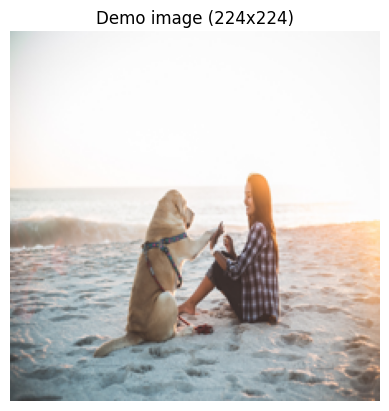

In [ ]:
from PIL import Image
import requests
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

img_url = 'https://storage.googleapis.com/sfr-vision-language-research/BLIP/demo.jpg'
raw_image = Image.open(requests.get(img_url, stream=True).raw).convert('RGB')
raw_image = raw_image.resize((224, 224))  # standard ViT input size

plt.imshow(raw_image)
plt.axis('off')
plt.title('Demo image (224x224)')
plt.show()

# Part 1 — Patchify: Turning an Image into a Sequence of Tokens

The core trick of ViT: cut the image into fixed-size, non-overlapping squares (**patches**, e.g. 16x16 pixels), and treat each patch as one "word" in a sequence. A 224x224 image with 16x16 patches becomes a sequence of `(224/16) * (224/16) = 14 * 14 = 196` tokens.

In [ ]:
import torchvision.transforms as T

to_tensor = T.ToTensor()
img_tensor = to_tensor(raw_image)  # (C, H, W) = (3, 224, 224), values in [0, 1]

def patchify(img_tensor, patch_size):
    """Split (C, H, W) into (num_patches, C, P, P) non-overlapping patches."""
    C, H, W = img_tensor.shape
    P = patch_size
    assert H % P == 0 and W % P == 0, 'image size must be divisible by patch size'

    patches = img_tensor.unfold(1, P, P).unfold(2, P, P)      # (C, H/P, W/P, P, P)
    patches = patches.permute(1, 2, 0, 3, 4).contiguous()      # (H/P, W/P, C, P, P)
    num_patches = (H // P) * (W // P)
    patches = patches.view(num_patches, C, P, P)               # (num_patches, C, P, P)
    return patches

patch_size = 16
patches = patchify(img_tensor, patch_size)
print('Image shape:  ', tuple(img_tensor.shape))
print('Patches shape:', tuple(patches.shape), '<-- (num_patches, C, P, P)')
print('Flattened per-patch vector length:', patches.shape[1] * patches.shape[2] * patches.shape[3])

Image shape:   (3, 224, 224)
Patches shape: (196, 3, 16, 16) <-- (num_patches, C, P, P)
Flattened per-patch vector length: 768


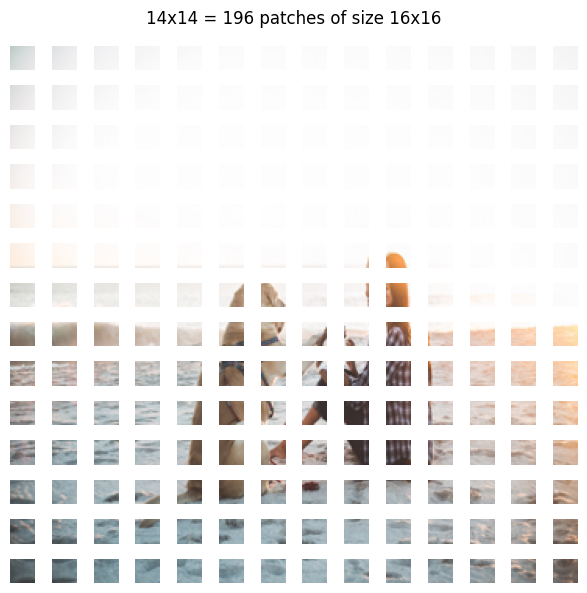

In [ ]:
# --- Visualize the patch grid ---
grid_size = 224 // patch_size
fig, axes = plt.subplots(grid_size, grid_size, figsize=(6, 6))
for idx, ax in enumerate(axes.flat):
    patch_img = patches[idx].permute(1, 2, 0).numpy()  # (P, P, C)
    ax.imshow(patch_img)
    ax.axis('off')
fig.suptitle(f'{grid_size}x{grid_size} = {grid_size*grid_size} patches of size {patch_size}x{patch_size}')
plt.tight_layout()
plt.show()

### 📌 Step 1b: Patch Embedding = Flatten + Linear Projection

Each raw patch is a `(C, P, P)` block of pixels. We flatten it into a single vector of length `C*P*P` and pass it through a **shared linear layer** to project it into the model's embedding dimension `D`. This projected vector is the **patch embedding** — the ViT equivalent of a word embedding.

In practice this "flatten + linear" is implemented as a single `nn.Conv2d(kernel_size=patch_size, stride=patch_size)`. That's not a coincidence — a convolution with a kernel exactly the size of the patch and no overlap performs precisely a per-patch linear projection. We verify this equivalence below.

In [ ]:
embed_dim = 192

# Method A: flatten each patch, apply one shared nn.Linear
flat_dim = 3 * patch_size * patch_size
linear_proj = nn.Linear(flat_dim, embed_dim)
flat_patches = patches.reshape(patches.shape[0], -1)          # (num_patches, C*P*P)
embed_via_linear = linear_proj(flat_patches)                  # (num_patches, D)

# Method B: a single strided Conv2d over the whole image
conv_proj = nn.Conv2d(3, embed_dim, kernel_size=patch_size, stride=patch_size)
# make the conv use the *same* weights as the linear layer, just reshaped
with torch.no_grad():
    conv_proj.weight.copy_(linear_proj.weight.view(embed_dim, 3, patch_size, patch_size))
    conv_proj.bias.copy_(linear_proj.bias)
embed_via_conv = conv_proj(img_tensor.unsqueeze(0))           # (1, D, H/P, W/P)
embed_via_conv = embed_via_conv.flatten(2).transpose(1, 2)[0]  # (num_patches, D)

print('Patch embedding shape:', tuple(embed_via_linear.shape))
print('Linear-flatten and strided-Conv2d give identical embeddings:',
      torch.allclose(embed_via_linear, embed_via_conv, atol=1e-5))

Patch embedding shape: (196, 192)
Linear-flatten and strided-Conv2d give identical embeddings: True


# Part 2 — The [CLS] Token and Positional Embeddings

Two things are still missing before we can feed our 196 patch embeddings to a Transformer:

1. **Positional embeddings.** Self-attention is *permutation-invariant* — it has no idea that patch 5 sits above patch 19. We add a learnable vector per position to every patch embedding so the model can recover spatial layout.
2. **The [CLS] token.** We prepend one extra learnable embedding to the sequence (borrowed straight from BERT). It doesn't correspond to any patch — its only job is to attend to every patch through self-attention and, after the final layer, summarize the whole image into a single vector that we feed to the classifier.

After this step the sequence length grows from `num_patches` to `num_patches + 1`.

In [ ]:
num_patches = embed_via_linear.shape[0]

cls_token = nn.Parameter(torch.zeros(1, embed_dim))
pos_embed = nn.Parameter(torch.zeros(num_patches + 1, embed_dim))
nn.init.trunc_normal_(cls_token, std=0.02)
nn.init.trunc_normal_(pos_embed, std=0.02)

sequence = torch.cat([cls_token, embed_via_linear], dim=0)  # (1 + num_patches, D)
sequence = sequence + pos_embed

print('Patch embeddings only:      ', tuple(embed_via_linear.shape))
print('+ [CLS] token:               ', tuple(sequence.shape))
print('Position 0 is always [CLS]; positions 1..N are the 14x14 grid of patches, read left-to-right, top-to-bottom.')

Patch embeddings only:       (196, 192)
+ [CLS] token:                (197, 192)
Position 0 is always [CLS]; positions 1..N are the 14x14 grid of patches, read left-to-right, top-to-bottom.


# Part 3 — Multi-Head Self-Attention (MHSA)

This is the heart of the Transformer. For every token, we compute three vectors: a **Query**, a **Key**, and a **Value**. A token "asks a question" with its query, every other token "advertises what it has" with its key, and the match between the two (via a dot product) decides how much of each token's value gets mixed into the output.

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

**Multi-head** means we don't do this once with the full embedding dimension — we split it into `num_heads` smaller chunks and run attention independently in each, so different heads can learn to attend to different kinds of relationships (e.g. one head tracks color, another tracks position). The results are concatenated back together at the end.

In [ ]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0, 'embed_dim must be divisible by num_heads'
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, N, D = x.shape  # batch, num_tokens, embed_dim

        qkv = self.qkv(x)                                            # (B, N, 3*D)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)                              # (3, B, heads, N, head_dim)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn_scores = (q @ k.transpose(-2, -1)) * self.scale          # (B, heads, N, N)
        attn_weights = attn_scores.softmax(dim=-1)                    # each row sums to 1
        attn_weights = self.dropout(attn_weights)

        out = attn_weights @ v                                        # (B, heads, N, head_dim)
        out = out.transpose(1, 2).reshape(B, N, D)                    # merge heads back together
        out = self.proj(out)
        return out, attn_weights

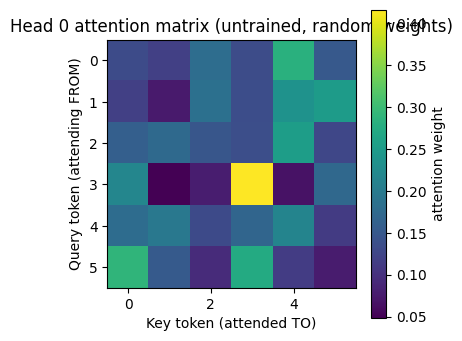

Each row sums to 1 (it is a softmax distribution): tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
       grad_fn=<SumBackward1>)


In [ ]:
# --- Toy example: attention weights on a handful of tokens ---
torch.manual_seed(0)
toy_tokens = torch.randn(1, 6, 16)  # (batch=1, tokens=6, embed_dim=16)
toy_mhsa = MultiHeadSelfAttention(embed_dim=16, num_heads=2)
_, toy_attn = toy_mhsa(toy_tokens)

plt.figure(figsize=(4, 4))
plt.imshow(toy_attn[0, 0].detach().numpy(), cmap='viridis')
plt.colorbar(label='attention weight')
plt.xlabel('Key token (attended TO)')
plt.ylabel('Query token (attending FROM)')
plt.title('Head 0 attention matrix (untrained, random weights)')
plt.show()
print('Each row sums to 1 (it is a softmax distribution):', toy_attn[0, 0].sum(dim=-1))

# Part 4 — The Transformer Encoder Block

ViT uses the **pre-norm** design: normalize *before* each sub-layer, then add its output back onto the input (a **residual connection**):

```
x = x + SelfAttention(LayerNorm(x))
x = x + MLP(LayerNorm(x))
```

- **LayerNorm** keeps activations well-scaled at every layer, which is essential for training deep Transformers.
- **Residual connections** give gradients a direct path back to earlier layers (and to the input), which is what makes it possible to stack many blocks without training collapsing.
- The **MLP** (`Linear -> GELU -> Linear`, usually expanding to 4x the embedding dimension) lets each token process the information it just gathered from attention, independently of every other token.

In [ ]:
class MLP(nn.Module):
    def __init__(self, embed_dim, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        hidden_dim = int(embed_dim * mlp_ratio)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)
        return x


class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, mlp_ratio, dropout)

    def forward(self, x):
        attn_out, attn_weights = self.attn(self.norm1(x))
        x = x + attn_out                 # residual connection #1
        x = x + self.mlp(self.norm2(x))  # residual connection #2
        return x, attn_weights

# Part 5 — Stacking It All Together: A Vanilla ViT

Now we assemble every piece from Parts 1-4 into a single `VisionTransformer` module:

`PatchEmbedding -> [CLS] + positions -> N x TransformerEncoderBlock -> final LayerNorm -> take [CLS] -> Linear head`

The only new ingredient is **stacking `depth` encoder blocks** — each block lets tokens exchange information with every other token once more, so deeper models can build increasingly global, abstract representations of the image.

In [ ]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=192):
        super().__init__()
        assert img_size % patch_size == 0, 'image size must be divisible by patch size'
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)          # (B, embed_dim, H/P, W/P)
        x = x.flatten(2)          # (B, embed_dim, num_patches)
        x = x.transpose(1, 2)     # (B, num_patches, embed_dim)
        return x


class VisionTransformer(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3, num_classes=1000,
                 embed_dim=192, depth=6, num_heads=3, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.dropout = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x, return_attention=False):
        B = x.shape[0]
        x = self.patch_embed(x)                             # (B, num_patches, D)

        cls_tokens = self.cls_token.expand(B, -1, -1)        # (B, 1, D)
        x = torch.cat([cls_tokens, x], dim=1)                # (B, num_patches+1, D)
        x = x + self.pos_embed
        x = self.dropout(x)

        attentions = []
        for block in self.blocks:
            x, attn_weights = block(x)
            attentions.append(attn_weights)

        x = self.norm(x)
        cls_final = x[:, 0]                                  # the [CLS] token's final representation
        logits = self.head(cls_final)

        if return_attention:
            return logits, attentions
        return logits

In [ ]:
# --- Sanity check: instantiate a small ViT and run one forward pass ---
toy_vit = VisionTransformer(
    img_size=224, patch_size=16, num_classes=10,   # 10 toy classes
    embed_dim=192, depth=4, num_heads=3,
)

batch = img_tensor.unsqueeze(0)  # (1, 3, 224, 224)
logits = toy_vit(batch)

num_params = sum(p.numel() for p in toy_vit.parameters())
print('Input shape: ', tuple(batch.shape))
print('Output shape:', tuple(logits.shape), '<-- (batch, num_classes), one logit per class')
print(f'Total parameters in this tiny ViT: {num_params:,}')

Input shape:  (1, 3, 224, 224)
Output shape: (1, 10) <-- (batch, num_classes), one logit per class
Total parameters in this tiny ViT: 1,967,434


### 📌 Sanity Check: How Do Patch Size and Depth Change Things?

- **Sequence length** = `(img_size / patch_size)^2 + 1`. A *smaller* patch size means *more* tokens — finer detail, but self-attention cost grows **quadratically** with sequence length, so this gets expensive fast.
- **Depth** (number of stacked encoder blocks) and **embed_dim** (hidden size) control model capacity, exactly like depth/width in a CNN or MLP.

In [ ]:
for patch_size_try in [32, 16, 8]:
    n = (224 // patch_size_try) ** 2
    print(f'patch_size={patch_size_try:2d} -> {n:4d} patches -> sequence length {n + 1:4d} (with [CLS])')

patch_size=32 ->   49 patches -> sequence length   50 (with [CLS])
patch_size=16 ->  196 patches -> sequence length  197 (with [CLS])
patch_size= 8 ->  784 patches -> sequence length  785 (with [CLS])


# Part 6 — Using a Real Pretrained ViT (Hugging Face)

Our toy ViT above has random weights and was never trained — it has no idea what it's looking at. The original ViT paper needed hundreds of millions of images (JFT-300M) to train from scratch. In practice, we always start from **pretrained weights**. Let's load a real, trained ViT (`google/vit-base-patch16-224`, ViT-B/16) and classify our demo image on the 1000 ImageNet classes, to confirm everything we just built conceptually matches a real working model.

In [ ]:
from transformers import ViTImageProcessor, ViTForImageClassification

processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
hf_vit = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224', attn_implementation="eager").to(device)
hf_vit.eval()

print('ViT-B/16 config: embed_dim =', hf_vit.config.hidden_size,
      '| depth =', hf_vit.config.num_hidden_layers,
      '| num_heads =', hf_vit.config.num_attention_heads,
      '| patch_size =', hf_vit.config.patch_size)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViT-B/16 config: embed_dim = 768 | depth = 12 | num_heads = 12 | patch_size = 16


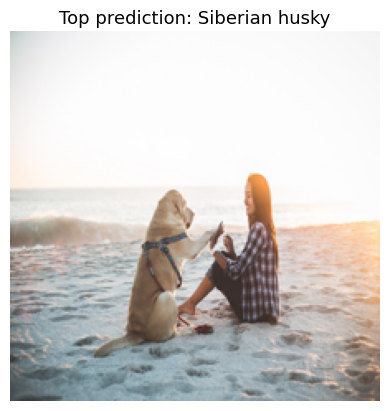

Top-5 predictions:
  Siberian husky                 12.26%
  seashore, coast, seacoast, sea-coast 10.39%
  Eskimo dog, husky               4.86%
  Saluki, gazelle hound           4.74%
  sandbar, sand bar               4.58%


In [ ]:
inputs = processor(images=raw_image, return_tensors='pt').to(device)

with torch.no_grad():
    outputs = hf_vit(**inputs)
    probs = outputs.logits.softmax(dim=-1)[0]

top5 = torch.topk(probs, k=5)
plt.imshow(raw_image)
plt.axis('off')
plt.title(f'Top prediction: {hf_vit.config.id2label[top5.indices[0].item()]}', fontsize=13, wrap=True)
plt.show()

print('Top-5 predictions:')
for score, idx in zip(top5.values, top5.indices):
    print(f'  {hf_vit.config.id2label[idx.item()]:30s} {score.item()*100:5.2f}%')

### 📌 Bonus: Peeking at Attention — What Is the ViT Looking At?

We can request the raw attention weights from every layer with `output_attentions=True`. As a quick (crude) saliency map, we take the last layer's attention **from the [CLS] token to every patch**, averaged across heads, and reshape it back into the 14x14 patch grid. High values roughly show which patches the model relied on most to make its final decision — the same [CLS]-token mechanism we built by hand in Part 2.

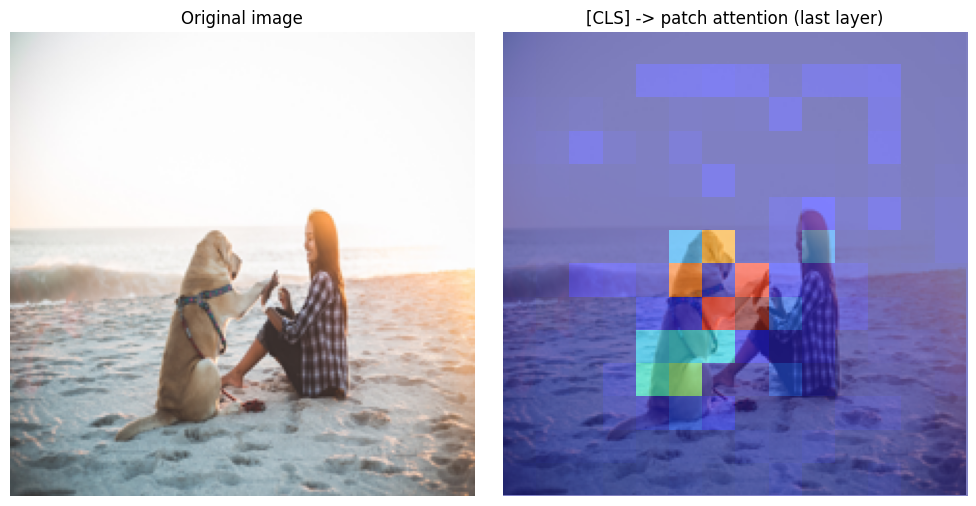

In [ ]:
with torch.no_grad():
    outputs = hf_vit(**inputs, output_attentions=True)

last_layer_attn = outputs.attentions[-1][0]              # (num_heads, seq_len, seq_len)
cls_to_patches = last_layer_attn[:, 0, 1:]                # attention FROM [CLS] TO every patch, all heads
cls_to_patches = cls_to_patches.mean(dim=0)               # average over heads -> (num_patches,)

grid_size = int(cls_to_patches.shape[0] ** 0.5)           # 14 for ViT-B/16 @ 224px
# Added .cpu() before .numpy() to fix the device error
attn_map = cls_to_patches.reshape(grid_size, grid_size).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(raw_image)
axes[0].set_title('Original image')
axes[0].axis('off')

axes[1].imshow(raw_image)
axes[1].imshow(attn_map, cmap='jet', alpha=0.5, extent=(0, 224, 224, 0))
axes[1].set_title('[CLS] -> patch attention (last layer)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# From ViT to CLIP & BLIP — Why This Matters

Everything you just built by hand is the **image encoder** hiding inside both of the other notebooks in this folder:

- **`CLIP.ipynb`**: `CLIPModel`'s vision tower is a ViT identical in structure to the one above (patch embedding → [CLS]/positional embeddings → stacked encoder blocks → final [CLS] representation). Instead of a classification head, that final [CLS] vector is projected into a shared embedding space and compared against a **text encoder's** output via a contrastive loss — that's `logits_per_image` in the CLIP notebook.
- **`BLIP.ipynb`**: `BlipForConditionalGeneration`'s vision encoder is also a ViT. Instead of pooling to a single [CLS] vector, BLIP keeps the **whole sequence of patch tokens** and feeds it into a text decoder's **cross-attention** layers — the decoder "attends over" the image tokens the same way our `MultiHeadSelfAttention` let tokens attend over each other, just across two modalities instead of within one.

So: patchify → embed → [CLS] + position → attend → residual + MLP is the shared vocabulary underneath image classification (this notebook), image-text matching (CLIP), and image captioning / VQA (BLIP).

## 🎯 Exercises for Students

1. **Sequence length vs. compute.** If you switch `patch_size` from 16 to 8 on a 224x224 image, how many tokens do you get? Self-attention cost scales as O(N²) in the number of tokens — how much more expensive does one encoder block become?
2. **Positional embeddings.** Comment out `x = x + self.pos_embed` in `VisionTransformer.forward` and re-run the sanity check in Part 5. The shapes still work — so what, conceptually, has the model lost?
3. **Why [CLS] instead of average pooling?** Some ViT variants skip the [CLS] token entirely and just average-pool all patch embeddings at the end. What could the model potentially learn with a dedicated [CLS] token that plain averaging cannot express?
4. **Read the attention map.** In the Part 6 bonus, does the highlighted region actually correspond to the salient object in the image? Try a different image URL and see if it still holds.
5. **Bridge to CLIP.** Open `CLIP.ipynb` and find the line that loads `CLIPModel`. Using what you learned here, what do you think `outputs.logits_per_image` is actually built from under the hood?
6. **Bridge to BLIP.** Open `BLIP.ipynb`. BLIP's text decoder generates captions one word at a time while attending over the ViT's patch tokens. Which part of *this* notebook is most analogous to that cross-attention step?